# Tarefa 2

In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from transformers import ViTModel, ViTImageProcessor, SwinModel, AutoImageProcessor
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

# 1 Cargar o dataset e o modelo da tarefa 1

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Clonar o repositorio e acceder ao directorio de train
# ou usar o directorio se xa existe no sistema

if os.path.exists("./tiny-imagenet-200/"):
    print("Xa existe o directorio :)")
    train = "./tiny-imagenet-200/train/"
elif not os.path.exists("./IMagenet/"):
    print("Clonando Tiny ImageNet desde GitHub... :)")
    os.system("git clone https://github.com/seshuad/IMagenet.git")
    print("Clonado exitosamente")
    train = "./IMagenet/tiny-imagenet-200/train/"
else:
    train = "./IMagenet/tiny-imagenet-200/train/"

# Cargar o mesmo modelo ViT da tarefa 1

print("Cargando modelo ViT")

procesador = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTModel.from_pretrained('google/vit-base-patch16-224')
model.eval() # Modo avaliación

print(f"Usando dispositivo: {device}")
model.to(device)

# Transformacións necesarias para ViT (Reseize a 224x224 e Normalización)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=procesador.image_mean, std=procesador.image_std)
])

full_dataset = datasets.ImageFolder(root=train, transform=transform)


Clonando Tiny ImageNet desde GitHub... :)
Clonado exitosamente
Cargando modelo ViT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Usando dispositivo: cuda


#  2. CARGA DE MODELOS 

In [ ]:
swin = "microsoft/swin-tiny-patch4-window7-224"
procesador_swin = AutoImageProcessor.from_pretrained(swin)
modelo_swin = SwinModel.from_pretrained(swin).to(device).eval()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#  3. FUNCIÓN DE INDEXACIÓN 

In [4]:
def index(model, dataloader, is_swin=False):
    features_lista = []
    labels_lista = []

    with torch.inference_mode():
        for imgs, labels in tqdm(dataloader, desc="Indexando"):
            imgs = imgs.to(device, non_blocking=True)
            outputs = model(imgs)

            if is_swin:
                feats = outputs.pooler_output
            else:
                feats = outputs.last_hidden_state[:, 0, :]

            feats = F.normalize(feats, p=2, dim=1)
            features_lista.append(feats.cpu())
            labels_lista.append(labels)

    return torch.cat(features_lista), torch.cat(labels_lista)

# Indexamos un subconxunto significativo
n_clases_avaliar = 50
indices = [idx for idx, (_, label) in enumerate(full_dataset.samples) if label < n_clases_avaliar]
subset_dataset = Subset(full_dataset, indices)

loader = DataLoader(
    subset_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=os.cpu_count(),
    pin_memory=(device.type == "cuda"),
    persistent_workers=True
)

print("\nIndexando con ViT...")
feats_vit, labels_vit = index(modelo_vit, loader, is_swin=False)

print("\nIndexando con Swin...")
feats_swin, labels_swin = index(modelo_swin, loader, is_swin=True)


Indexando con ViT...


Indexando: 100%|██████████| 196/196 [04:28<00:00,  1.37s/it]



Indexando con Swin...


Indexando: 100%|██████████| 196/196 [02:12<00:00,  1.48it/s]


#  4. IMPLEMENTACIÓN DA BUSCA E AVALIACIÓN 

In [5]:
def evaluate_retrieval(features, labels, k=5):
    # Calculamos similitude coseno (como están normalizados, é o produto matricial)
    # Resultado: matriz [N x N]
    sim_matrix = torch.mm(features, features.t())
    
    # Evitamos que unha imaxe se atope a si mesma poñendo similitude -1 na diagonal
    sim_matrix.fill_diagonal_(-1)
    
    # Obtemos os K índices máis similares
    _ , topk_indices = torch.topk(sim_matrix, k, dim=1)
    
    # Comprobamos cantos acertos (mesma categoría) hai nos top K
    query_labels = labels.view(-1, 1).expand_as(topk_indices)
    retrieved_labels = labels[topk_indices]
    
    correct_matches = (query_labels == retrieved_labels).float()
    
    # Precision@K: media de acertos no top K
    precision_at_k = correct_matches.mean().item()
    
    # Recall@K (Simplificado): porcentaxe de consultas que teñen polo menos 1 acerto no top K
    # (Ou tamén se pode facer sobre o total de imaxes da clase, pero P@K é o estándar aquí)
    has_at_least_one_correct = (correct_matches.sum(dim=1) > 0).float().mean().item()
    
    return precision_at_k, has_at_least_one_correct

# Executamos a avaliación
k_val = 5
p_vit, r_vit = evaluate_retrieval(feats_vit, labels_vit, k=k_val)
p_swin, r_swin = evaluate_retrieval(feats_swin, labels_swin, k=k_val)

print(f"\n RESULTADOS DE AVALIACIÓN (K={k_val}) ")
print(f"ViT  -> Precision@{k_val}: {p_vit:.4f} | Recall@{k_val} (at least 1): {r_vit:.4f}")
print(f"Swin -> Precision@{k_val}: {p_swin:.4f} | Recall@{k_val} (at least 1): {r_swin:.4f}")




 RESULTADOS DE AVALIACIÓN (K=5) 
ViT  -> Precision@5: 0.8475 | Recall@5 (at least 1): 0.9419
Swin -> Precision@5: 0.7175 | Recall@5 (at least 1): 0.8868


#  5. VISUALIZACIÓN DUN EXEMPLO 


Amosando exemplo de busca visual con Swin:


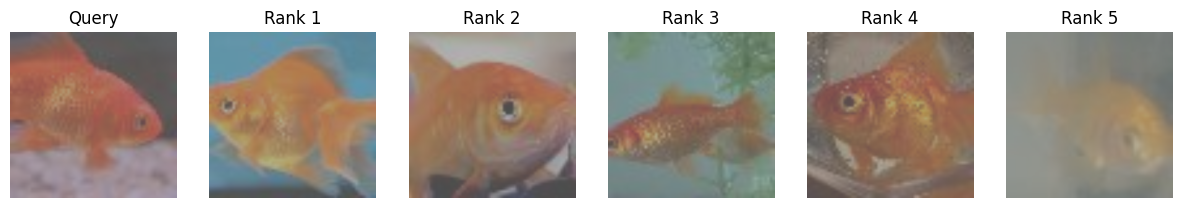

In [6]:
def show_search_result(query_idx, features, dataset, k=5):
    query_feat = features[query_idx].unsqueeze(0)
    sims = torch.mm(query_feat, features.t())
    sims[0, query_idx] = -1
    _, topk = torch.topk(sims, k)
    
    fig, axes = plt.subplots(1, k+1, figsize=(15, 5))
    
    # Query
    axes[0].imshow(dataset[query_idx][0].permute(1,2,0).numpy() * 0.2 + 0.5) # Des-normalización simple para ver
    axes[0].set_title("Query")
    axes[0].axis('off')
    
    # Resultados
    for i, res_idx in enumerate(topk[0]):
        axes[i+1].imshow(dataset[res_idx][0].permute(1,2,0).numpy() * 0.2 + 0.5)
        axes[i+1].set_title(f"Rank {i+1}")
        axes[i+1].axis('off')
    plt.show()

print("\nAmosando exemplo de busca visual con Swin:")
show_search_result(100, feats_swin, subset_dataset)